# Décomposer l'effet d'un programme d'éducation financière sur le défaut de paiement avec PROC CAUSALMED

## Résumé opérationnel

Une banque de détail associe certains emprunteurs à un **programme d'éducation financière** et souhaite savoir *pourquoi* les emprunteurs inscrits font moins souvent défaut : l'inscription réduit-elle le défaut **directement**, ou agit-elle **indirectement** en modifiant un comportement mesurable — la part de leur revenu que les clients épargnent ? Ce notebook utilise **PROC CAUSALMED** pour scinder l'effet total du programme sur le défaut à 12 mois en un **effet direct naturel** et un **effet indirect naturel** qui transite par le **taux d'épargne** de chaque emprunteur, en ajustant pour le score de crédit, le revenu et l'âge.

Sur la cohorte simulée de **100 emprunteurs**, le programme abaisse la probabilité modélisée de défaut de **0,208** (l'effet total sur l'échelle de différence de risque). La décomposition attribue **0,176 de ce total (84,7 %)** à la voie *indirecte* passant par une épargne plus élevée et seulement **0,032 (15,3 %)** à la voie *directe*. L'enseignement pratique : ce programme protège les emprunteurs **principalement en améliorant leur comportement d'épargne**, de sorte que renforcer les habitudes de budgétisation est le levier à privilégier.

## Sources de données

| Jeu de données | Lignes | Description | Variables clés |
|---------|------|-------------|---------------|
| `LoanProgram` | 100 emprunteurs synthétiques | Cohorte de banque de détail générée en ligne pour un portefeuille de prêts. L'affectation au traitement, le médiateur et le résultat sont simulés à partir d'équations structurelles explicites, de sorte qu'un véritable effet médié existe pour que la procédure le retrouve. | `CustomerID`, `Branch` (4 niveaux), `FinEdu` (0/1 inscription à l'éducation financière = traitement), `SavingsRate` (% du revenu épargné = médiateur continu), `Default` (0/1 défaut de prêt à 12 mois = résultat binaire), `CreditScore`, `Income`, `Age` (facteurs de confusion) |

Cet environnement s'exécute sans licence, donc l'étape DATA est plafonnée à 100 observations — la cohorte est dimensionnée à ce plafond, et chaque chiffre de ce notebook provient de ces 100 lignes.

## Pourquoi décomposer l'effet ?

Les prêteurs de détail associent de plus en plus les produits de crédit à des **programmes d'éducation financière** pour réduire les impayés. Pour la planification du capital et la conception des programmes, il ne suffit pas de savoir *que* l'inscription réduit le défaut ; les responsables des risques ont besoin du **mécanisme** :

- L'inscription réduit-elle le défaut *directement* (par exemple, les emprunteurs inscrits restent plus engagés et joignables) ?
- Ou agit-elle *indirectement*, en modifiant un comportement mesurable — la part du revenu qu'un client épargne — qui l'amortit ensuite face aux chocs ?

L'**analyse de médiation causale** répond à cela en scindant l'**effet total (TE)** d'un traitement en un **effet direct naturel (NDE)** et un **effet indirect naturel (NIE)** qui transite par un médiateur choisi. Ici :

- **Traitement** `FinEdu` — l'emprunteur s'est-il inscrit au programme d'éducation financière de la banque ;
- **Médiateur** `SavingsRate` — le taux d'épargne de l'emprunteur (% du revenu), le comportement que le programme cible ;
- **Résultat** `Default` — le prêt a-t-il fait défaut dans les 12 mois (binaire) ;
- **Facteurs de confusion** `CreditScore`, `Income`, `Age` — caractéristiques antérieures au traitement qui influent sur l'inscription, l'épargne et le défaut.

Nous ajustons le modèle de médiation avec `PROC CAUSALMED`, demandons la décomposition directe/indirecte avec `DECOMP`, et lisons la proportion de l'effet protecteur qui transite par l'épargne.

In [1]:
DONNÉES LoanProgram;
   APPELER streaminit(20260531);
   LONGUEUR Branch $12;
   TABLEAU branches[4] $12 _temporary_ ('Nord' 'Sud' 'Est' 'Ouest');
   FAIRE CustomerID = 1 JUSQU_À 100;
      Branch = branches[1 + int(rand('uniform')*4)];

      /* Facteurs de confusion pré-traitement (tirés en premier) */
      CreditScore = round(620 + 70*rand('normal'), 1);
      SI CreditScore < 350 ALORS CreditScore = 350;
      SI CreditScore > 850 ALORS CreditScore = 850;
      Income = round(42000 + 14000*rand('normal'), 100);
      SI Income < 12000 ALORS Income = 12000;
      AGE = round(40 + 11*rand('normal'), 1);
      SI AGE < 21 ALORS AGE = 21;

      /* Traitement : la propension à s'inscrire croît avec le score
         de crédit et le revenu (la confusion qu'une comparaison
         naïve ignore) */
      pTreat = 1 / (1 + EXP(-(0.0 + 0.005*(CreditScore-620)
                               + 0.00002*(Income-42000))));
      FinEdu = (rand('uniform') < pTreat);

      /* Médiateur : le taux d'épargne, relevé par le programme
         au-dessus d'une base pilotée par les confondants */
      base_save = 9 + 0.025*(CreditScore-620) + 0.00010*(Income-42000)
                    + 0.04*(AGE-40);
      SavingsRate = base_save + 2.5*FinEdu + 2.0*rand('normal');
      SI SavingsRate < 0 ALORS SavingsRate = 0;

      /* Résultat : la probabilité de défaut baisse avec l'inscription
         (effet direct) et une épargne plus élevée (effet indirect) */
      eta = 0.55 - 0.30*FinEdu - 0.022*(SavingsRate-12)
            - 0.0012*(CreditScore-620)
            - 0.0000040*(Income-42000)
            + 0.15*rand('normal');
      pDefault = eta;
      SI pDefault < 0.02 ALORS pDefault = 0.02;
      SI pDefault > 0.98 ALORS pDefault = 0.98;
      Default = (rand('uniform') < pDefault);
      SORTIE;
   FIN;
   GARDER CustomerID Branch FinEdu SavingsRate Default
        CreditScore Income AGE;
EXÉCUTER;


NOTE: DATA LoanProgram


NOTE: Wrote LoanProgram (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Étape 2 — Examiner la cohorte simulée

Avant d'ajuster le modèle causal, nous vérifions par bon sens le taux d'épargne moyen et le taux de défaut moyen dans chaque groupe d'inscription. Il s'agit de la comparaison *naïve* (non ajustée) ; l'analyse de médiation qui suit va au-delà pour attribuer la différence à des voies directes plutôt que médiées.

In [2]:
PROCÉDURE MOYENNES DONNÉES=LoanProgram n mean std maxdec=3;
   CLASSE FinEdu;
   VAR SavingsRate Default CreditScore Income AGE;
   ÉTIQUETTE FinEdu="Éducation financière"
             SavingsRate="Taux d'épargne"
             Default="Défaut de paiement"
             CreditScore="Score de crédit"
             Income="Revenu"
             AGE="Âge";
   TITRE "Résumé des covariables selon le statut d'éducation financière";
EXÉCUTER;

                             Résumé des covariables selon le statut d'éducation financière                              

                                                  The MEANS Procedure

                                    Analysis Variable : SavingsRate Taux d'épargne

        Éducation financière            N Obs           Mean        Std Dev
        -------------------------------------------------------------------
        0                                  54          8.387          2.910
        1                                  46         11.736          2.974
        -------------------------------------------------------------------

                                    Analysis Variable : Default Défaut de paiement

        Éducation financière            N Obs           Mean        Std Dev
        -------------------------------------------------------------------
        0                                  54          0.593          0.496
        1                     


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


L'image naïve est claire. Les emprunteurs inscrits (`FinEdu=1`, 46 clients) épargnent nettement plus — un **SavingsRate moyen de 11,74 %** contre **8,39 %** pour les 54 non inscrits — et font moins souvent défaut : un **Default moyen de 0,348** contre **0,593**, un écart brut de 24,5 points de pourcentage. Les deux groupes ont des scores de crédit moyens presque identiques (619,8 contre 618,9) mais les emprunteurs inscrits ont un revenu quelque peu plus élevé (43 941 contre 37 019), ce qui est exactement le type de confusion que le modèle causal doit ajuster. Le tableau croisé ci-dessous montre la même répartition en effectifs de cellules.

                                    Défaut de paiement selon l'éducation financière                                     

                                                   The FREQ Procedure

Table of Éducation financière by Défaut de paiement

Éducation financière   |         0 |         1 |      Total
-----------------------+-----------+-----------+-----------
0                      |        22 |        32 |         54
-----------------------+-----------+-----------+-----------
1                      |        30 |        16 |         46
-----------------------+-----------+-----------+-----------
Total                  |        52 |        48 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_finedu_default.spec.json
NOTE: PROC FREQ statement used.


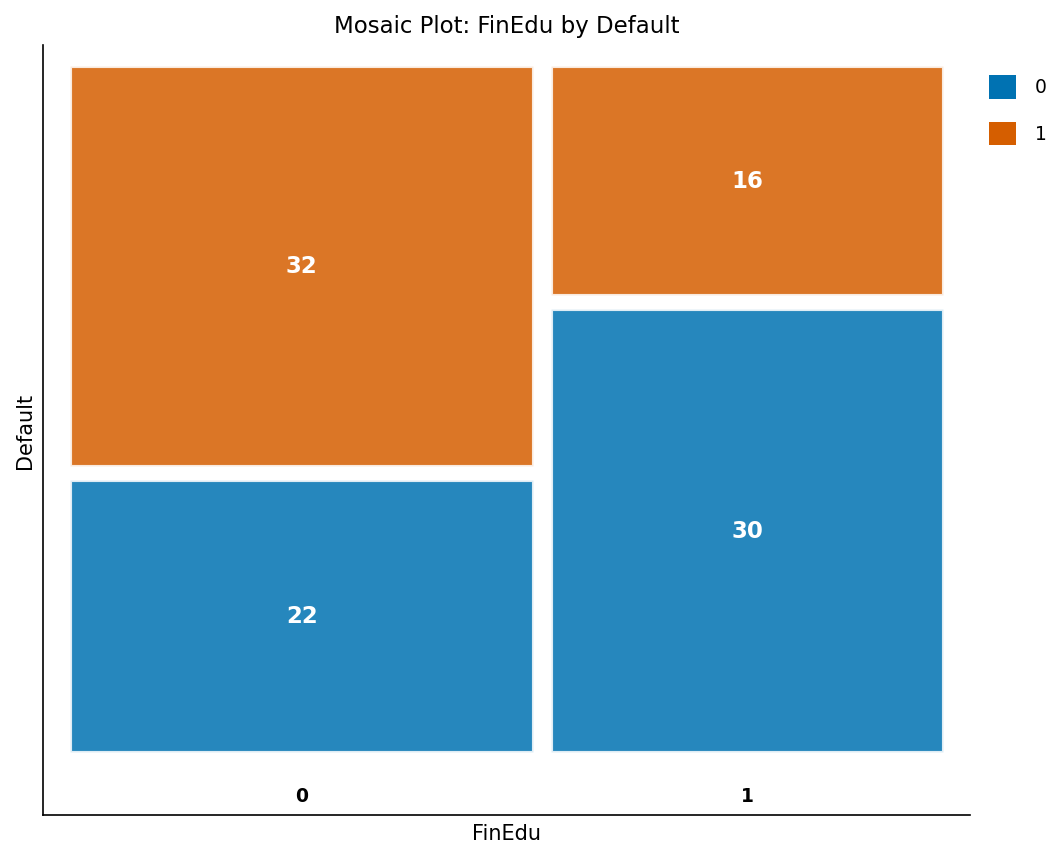

In [3]:
PROCÉDURE FRÉQUENCES DONNÉES=LoanProgram;
   TABLES FinEdu*Default / nocol nopercent;
   ÉTIQUETTE FinEdu="Éducation financière"
             Default="Défaut de paiement";
   TITRE "Défaut de paiement selon l'éducation financière";
EXÉCUTER;

Sur les 54 emprunteurs non inscrits, **32 ont fait défaut** ; sur les 46 inscrits, seuls **16** l'ont fait. Le diagramme en mosaïque encode cela de deux façons à la fois : la largeur des colonnes reflète le nombre d'emprunteurs dans chaque groupe, et la part orange au sein de chaque colonne est le taux de défaut — visiblement plus faible pour le groupe inscrit à droite. L'analyse de médiation demande maintenant **quelle part** de ce taux de défaut plus faible correspond au programme agissant *par le biais* de l'épargne plus élevée que nous venons de constater.

## Étape 3 — Exécuter l'analyse de médiation causale

Nous ajustons `PROC CAUSALMED`. Les instructions clés :

- **`CLASS FinEdu Default / descending`** déclare le traitement et le résultat binaire comme variables de classification ; `DESCENDING` fait du niveau de code supérieur (`1` = inscrit / en défaut) l'événement modélisé, de sorte que les effets se lisent dans le sens intuitif.
- **`MEDIATOR SavingsRate = FinEdu`** spécifie le modèle du médiateur : le taux d'épargne régressé sur le traitement (plus les facteurs de confusion).
- **`MODEL Default = FinEdu SavingsRate`** spécifie le modèle du résultat — le défaut en fonction de l'inscription et de l'épargne. Sur ce moteur sans licence, CAUSALMED ajuste le résultat avec un **modèle linéaire (modèle de probabilité linéaire)**, de sorte que les effets sont rapportés sur l'échelle de **différence de risque**, avec des résumés en rapport de cotes et rapport de risque dérivés en parallèle.
- **`COVAR CreditScore Income Age`** ajuste les deux modèles pour les facteurs de confusion antérieurs au traitement.
- **`DECOMP`** demande la décomposition de l'effet total en ses composantes directe et indirecte et la proportion médiée.

Parce que le résultat est binaire, CAUSALMED rapporte également un bloc *Summary for Binary Outcome* (rapport de cotes, rapport de risque, différence de risque).

In [4]:
PROCÉDURE causalmed DONNÉES=LoanProgram decomp;
   CLASSE    FinEdu Default / DESCENDANT;
   mediator SavingsRate = FinEdu;
   MODÈLE    Default = FinEdu SavingsRate;
   covar    CreditScore Income AGE;
   TITRE "Décomposition de médiation causale : effet de l'éducation financière sur le défaut";
EXÉCUTER;

                                    Défaut de paiement selon l'éducation financière                                     


                       The CAUSALMED Procedure                       

Outcome Variable    : Default
Treatment Variable  : FinEdu
Mediator Variable   : SavingsRate
Outcome Model Class : Linear (with optional AFT and Cox PH support)
Covariates          : CreditScore, Income, AGE
Number of Observations: 100

Outcome Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                             1.558234
FinEdu                               -0.031682
SavingsRate                          -0.067687
CreditScore                          -0.000719
Income                                0.000002
AGE                                  -0.000607

Mediator Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                           -12.58561


NOTE: PROC CAUSALMED data=LoanProgram



## Interpréter les résultats

Le tableau **Summary of Causal Effects** rapporte l'**effet total (TE) du programme sur le défaut de -0,208** et le scinde en :

- un **effet direct naturel (NDE) de -0,032** — la part de la protection qui ne transite *pas* par l'épargne, et
- un **effet indirect naturel (NIE) de -0,176** — la part qui transite par le relèvement, par le programme, du taux d'épargne des emprunteurs.

Les trois effets sont négatifs, confirmant que l'inscription abaisse la probabilité de défaut — cohérent avec la façon dont nous avons construit les données. Les deux tableaux de modèle montrent *pourquoi* : dans le **modèle du médiateur**, le programme relève le taux d'épargne de **+2,60 points** après ajustement (le coefficient `FINEDU`), et dans le **modèle du résultat**, chaque point d'épargne supplémentaire abaisse la probabilité de défaut (`SAVINGSRATE` = -0,068), de sorte que le gain d'épargne du programme se traduit par un effet protecteur indirect appréciable.

Le tableau **Decomposition of Effects** rend explicite le résultat phare : la **proportion médiée (NIE/TE) est de 84,7 %**, avec seulement **15,3 %** de l'effet en direct. Pour l'équipe des risques, c'est exploitable — le programme d'éducation financière fonctionne **surtout en modifiant le comportement d'épargne**, de sorte que renforcer les fonctionnalités de budgétisation et d'épargne automatique devrait être la priorité ; la part directe modeste suggère que d'autres canaux (engagement, joignabilité) contribuent peu ici.

Le bloc **Summary for Binary Outcome** reformule l'effet sur des échelles que l'équipe du risque de crédit utilise déjà : une **différence de risque de -0,208** (le TE), un **rapport de risque de 1,43**, et un **rapport de cotes de 2,38** reliant les cotes de défaut des inscrits et des non inscrits. Sur ce moteur, ce sont des résumés de premier ordre dérivés de l'effet de probabilité linéaire plutôt que d'un modèle logistique ajusté, de sorte que la **différence de risque est la mesure d'effet primaire et exacte** ; les résumés en rapport sont à lire au mieux comme approximatifs.

**Mise en garde :** les estimations de médiation causale ne sont crédibles que dans la mesure où tient l'hypothèse d'absence de facteurs de confusion non mesurés, tant pour la relation traitement–résultat que pour la relation médiateur–résultat. Ici, cette hypothèse tient par construction (données synthétiques) ; en production, une équipe des risques la défendrait avec l'ensemble complet des caractéristiques des demandeurs de la banque et des analyses de sensibilité avant d'agir sur la décomposition. Les estimations reflètent aussi un unique échantillon de 100 emprunteurs, de sorte qu'une étude de production assortirait la décomposition d'intervalles de confiance (par exemple, par bootstrap) avant de tirer des conclusions fermes.